In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# The English reader standardises metadata as:
# Project, Test, Result_index, Result, Interval, expected_points.
#
# Measurement-column labels depend on the selected RheoCompass export.
# English labels are used first; legacy German labels remain as fallbacks so
# previously exported data can still be plotted.
COLUMN_ALIASES = {
    "test_time": [
        "Test Time [s]",
        "Time [s]",
        "Versuchszeit [s]",
        "Zeit [s]",
    ],
    "temperature": [
        "Temperature [°C]",
        "Temperatur [°C]",
    ],
    "storage_modulus": [
        "Storage Modulus [Pa]",
        "Speichermodul [Pa]",
    ],
    "loss_modulus": [
        "Loss Modulus [Pa]",
        "Verlustmodul [Pa]",
    ],
    "loss_factor": [
        "Loss Factor [1]",
        "Verlustfaktor [1]",
    ],
    "complex_viscosity": [
        "Complex Viscosity [Pa·s]",
        "Complex Viscosity [mPa·s]",
        "Komplexe Viskosität [Pa·s]",
        "Komplexe Viskosität [mPa·s]",
    ],
    "viscosity": [
        "Viscosity [Pa·s]",
        "Viscosity [mPa·s]",
        "Viskosität [Pa·s]",
        "Viskosität [mPa·s]",
    ],
    "shear_rate": [
        "Shear Rate [1/s]",
        "Scherrate [1/s]",
    ],
    "shear_strain": [
        "Shear Strain [1]",
        "Shear Deformation [1]",
        "Scherdeformation [1]",
    ],
}


def get_column(df, quantity):
    """Return the first matching export column for a named rheological quantity."""
    for column in COLUMN_ALIASES[quantity]:
        if column in df.columns:
            return column

    expected = "\n  - ".join(COLUMN_ALIASES[quantity])
    available = "\n  - ".join(map(str, df.columns))
    raise KeyError(
        f"Could not find a column for '{quantity}'.\n"
        f"Expected one of:\n  - {expected}\n"
        f"Available columns:\n  - {available}"
    )


In [3]:
# Optional: load one CSV file rather than an entire folder.

from Read_Rheodata_english import read_data
csv_path = Path("data/Gelatine 10% + TG 5mg_mL 1.csv")
metadata, sections, df_all = read_data(csv_path)


In [4]:
#Bulk import of a complete folder path with all CSV in it
'''
from Read_Rheodata_english import read_rheodata_folder

# Keep Read_Rheodata_english.py in the same folder as this notebook.
data_folder = Path("Rheo_Data_Raw") / "GelMa"  # <-- edit this folder path

metadata_all, sections_all, df_all = read_rheodata_folder(data_folder)

if df_all.empty:
    raise FileNotFoundError(
        f"No readable CSV data found in: {data_folder.resolve()}\n"
        "Check the folder path and confirm that the CSV exports are present."
    )

print(f"Loaded {len(df_all):,} rows from {len(metadata_all)} file(s).")
'''

'\nfrom Read_Rheodata_english import read_rheodata_folder\n\n# Keep Read_Rheodata_english.py in the same folder as this notebook.\ndata_folder = Path("Rheo_Data_Raw") / "GelMa"  # <-- edit this folder path\n\nmetadata_all, sections_all, df_all = read_rheodata_folder(data_folder)\n\nif df_all.empty:\n    raise FileNotFoundError(\n        f"No readable CSV data found in: {data_folder.resolve()}\n"\n        "Check the folder path and confirm that the CSV exports are present."\n    )\n\nprint(f"Loaded {len(df_all):,} rows from {len(metadata_all)} file(s).")\n'

In [5]:
# Save the combined dataframe as CSV --> edit the file name as needed.
out_path = Path("Processed_Rheodata") 
out_path.mkdir(parents=True, exist_ok=True)

filename = "Extracted_Rheodata.csv"  # <-- edit this name
df_all.to_csv(out_path / filename, index=False, sep=";", encoding="utf-8-sig")
print(f"Saved: {out_path / filename}")


Saved: Processed_Rheodata\Extracted_Rheodata.csv


In [6]:
df_all.columns

Index(['source_file', 'Project', 'Test', 'Result_index', 'Result', 'Interval',
       'expected_points', 'Point No.', 'Time [min]', 'Temperature [°C]',
       'Storage Modulus [Pa]', 'Loss Modulus [Pa]', 'Loss Factor [1]',
       'Complex Viscosity [Pa·s]', 'Gap [mm]', 'Normal Force [N]',
       'Torque [µN·m]', 'Status', 'Test Time [s]'],
      dtype='str')

In [7]:
df_all[
    [
        "source_file",
        "Project",
        "Test",
        "Result_index",
        "Result",
        "Interval",
        "expected_points",
    ]
].drop_duplicates()


,source_file,Project,Test,Result_index,Result,Interval,expected_points
0,Gelatine 10% + TG 5mg_mL 1.csv,"Isothermic Test Gelatine | MU15AC33010, 02.07....",Gelatine 10% + TG 5mg/mL 1,1,Time (oscillation) 1,1,600


In [8]:
df_all["measurement_id"] = (
    df_all["source_file"].astype(str)
    + " | "
    + df_all["Result_index"].astype(str)
    + " | "
    + df_all["Result"].astype(str)
)

df_all["measurement_id"].unique()


<StringArray>
['Gelatine 10% + TG 5mg_mL 1.csv | 1 | Time (oscillation) 1']
Length: 1, dtype: str

In [9]:
measurements = (
    df_all[["measurement_id", "source_file", "Project", "Test", "Result_index", "Result"]]
    .drop_duplicates()
    .sort_values(["source_file", "Result_index"])
)

measurements


,measurement_id,source_file,Project,Test,Result_index,Result
0,Gelatine 10% + TG 5mg_mL 1.csv | 1 | Time (osc...,Gelatine 10% + TG 5mg_mL 1.csv,"Isothermic Test Gelatine | MU15AC33010, 02.07....",Gelatine 10% + TG 5mg/mL 1,1,Time (oscillation) 1


In [10]:
# Build the dictionary in the same stable order used in the measurement overview.
measurement_ids = (
    df_all[["measurement_id", "source_file", "Result_index"]]
    .drop_duplicates()
    .sort_values(["source_file", "Result_index"])["measurement_id"]
    .tolist()
)

measurements = {
    idx: df_all.loc[df_all["measurement_id"] == measurement_id].copy()
    for idx, measurement_id in enumerate(measurement_ids)
}


In [11]:
measurement_overview = (
    df_all[["measurement_id", "source_file", "Project", "Test", "Result_index", "Result"]]
    .drop_duplicates()
    .sort_values(["source_file", "Result_index"])
    .reset_index(drop=True)
)

measurement_overview.insert(0, "idx", range(len(measurement_overview)))

measurement_overview


,idx,measurement_id,source_file,Project,Test,Result_index,Result
0,0,Gelatine 10% + TG 5mg_mL 1.csv | 1 | Time (osc...,Gelatine 10% + TG 5mg_mL 1.csv,"Isothermic Test Gelatine | MU15AC33010, 02.07....",Gelatine 10% + TG 5mg/mL 1,1,Time (oscillation) 1


In [12]:
overview_path = Path("Processed_Rheodata") / "Overview_index_xyz.csv" #<-- edit this name! #TODO: 
overview_path.parent.mkdir(parents=True, exist_ok=True)

measurement_overview.to_csv(
    overview_path,
    index=False,
    encoding="utf-8-sig",
)
print(f"Saved: {overview_path}")


Saved: Processed_Rheodata\Overview_index_xyz.csv


## Gelling curve

In [13]:
df_1 = measurements[0]
df_1.columns

Index(['source_file', 'Project', 'Test', 'Result_index', 'Result', 'Interval',
       'expected_points', 'Point No.', 'Time [min]', 'Temperature [°C]',
       'Storage Modulus [Pa]', 'Loss Modulus [Pa]', 'Loss Factor [1]',
       'Complex Viscosity [Pa·s]', 'Gap [mm]', 'Normal Force [N]',
       'Torque [µN·m]', 'Status', 'Test Time [s]', 'measurement_id'],
      dtype='str')

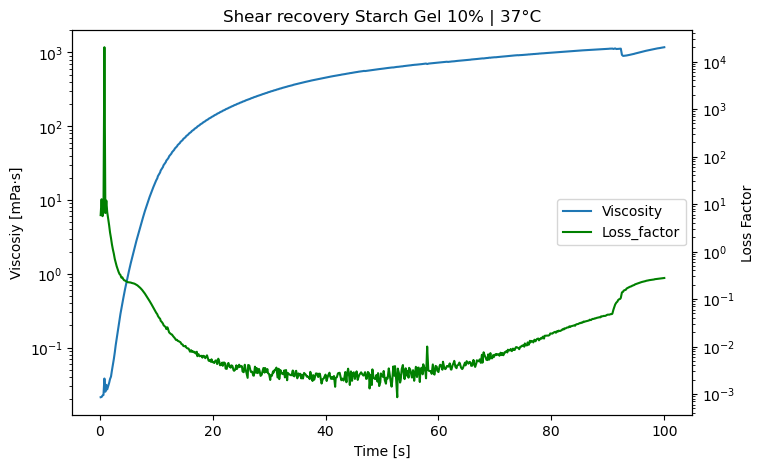

In [27]:
fig, ax1 = plt.subplots(figsize=(8, 5))

ax2 = ax1.twinx()

ax1.plot(df_1["Time [min]"],df_1["Complex Viscosity [Pa·s]"],label="Viscosity")
ax2.plot(df_1["Time [min]"],df_1["Loss Factor [1]"],label="Loss_factor",color="green")

ax1.set_ylabel("Viscosiy [mPa·s]")
ax2.set_ylabel("Loss Factor")
ax1.set_xlabel("Time [s]")

ax1.set_yscale("log")
ax2.set_yscale("log")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")
plt.title("Shear recovery Starch Gel 10% | 37°C")
plt.show()

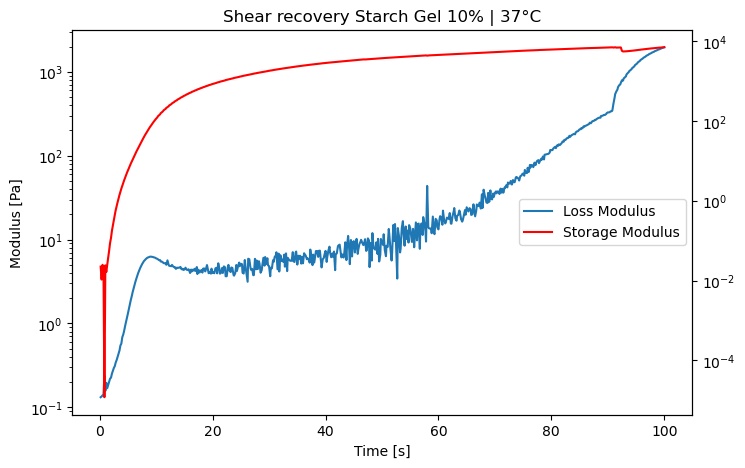

In [29]:
fig, ax1 = plt.subplots(figsize=(8, 5))

ax2 = ax1.twinx()

ax1.plot(df_1["Time [min]"],df_1["Loss Modulus [Pa]"],label="Loss Modulus")
ax2.plot(df_1["Time [min]"],df_1["Storage Modulus [Pa]"],label="Storage Modulus", color="red")    

ax1.set_ylabel("Modulus [Pa]")
ax1.set_xlabel("Time [s]")

ax1.set_yscale("log")
ax2.set_yscale("log")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")
plt.title("Shear recovery Starch Gel 10% | 37°C")
plt.show()